<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Classic_Machine_Learning/Automobile_Purchase_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ** Project: Automobile Purchase Prediction**

We have a dataset representing historical data of the potential candidates, registering for buying an automobile. Some of these candidates bought an automobile and some of them not. In this dataset, 0 indicates that a person did not buy a car, and 1 shows they did.
data is deposited at url = "https://github.com/kuroshkarimi/Machine-Learning-and-Data-Analysis/raw/refs/heads/main/Classic_Machine_Learning/Social_Network_Ads.csv".

This data has three columns:
1. Age: the age of the candidates
2. EstimatedSalary: the estimated salary of them (dollars / year)
3. Purchase: 0 (not buying), and 1 (buying)


# Task:

1) Use logistic Regression and exhibit the probability of people buying a car along with the actual data (if they bought it in reality or not). Set the threshold to 0.8.

2) According to that 0.8 threshold, what is the chance that somebody buys a car with the age 30 and estimated salary of 87500 dollars per year?

3) create and visualize a Confusion Matrix for evaluation of your model

4) calculate the accuracy, precession, recall, f1 scores, CAP curve (with AUC), as well as roc-curve (with AUC)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Loading the data and having a quick look its properties
url = "https://github.com/kuroshkarimi/Machine-Learning-and-Data-Analysis/raw/refs/heads/main/Classic_Machine_Learning/Social_Network_Ads.csv"
dataset = pd.read_csv(url)

dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
# Information about the null values and other parameters

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
# Statistical properties of this dataset

dataset.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
# Separating the features and target columns
X = dataset.drop('Purchased', axis=1).values
# values converts the format of the data from a data frame to a numpy array. This conversion is important because in the following
# we see that the machine learning model requires a numpy array for fitting the data

y = dataset.Purchased.values

In [7]:
# Splitting the data into train and test sets for using in the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [8]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Application of the Logistic Regression Model

from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train_scaled, y_train)
y_proba = classifier.predict_proba(X_test_scaled)[:, 1]
# predict probability gives the negative and positive probabilities, respectively. So, if we are working with the positives, we
# need to extract the positive predictions which are located at the second column of y_proba

y_proba

array([0.11275338, 0.16679594, 0.19452734, 0.08944762, 0.09748596,
       0.00787412, 0.01514882, 0.73214818, 0.00581025, 0.50427605,
       0.03605664, 0.02919452, 0.16067158, 0.36961651, 0.01549432,
       0.33490911, 0.27985627, 0.0122548 , 0.98859721, 0.04202128,
       0.08931479, 0.96330631, 0.27700752, 0.88210956, 0.00448994,
       0.97294682, 0.07768445, 0.07628906, 0.19341888, 0.15659393,
       0.0202005 , 0.29301096, 0.93218876, 0.15217937, 0.01434061,
       0.00347992, 0.01981547, 0.06559408, 0.02757035, 0.550607  ,
       0.06613068, 0.28349934, 0.05861051, 0.03950509, 0.80458944,
       0.02625618, 0.29972235, 0.92811378, 0.00883573, 0.85964712,
       0.99020717, 0.03784228, 0.11918377, 0.41602283, 0.98079689,
       0.32120487, 0.08337765, 0.0426624 , 0.48641468, 0.00347426,
       0.02038506, 0.93452989, 0.00920127, 0.39108213, 0.00185427,
       0.98162152, 0.0379613 , 0.02625618, 0.21521886, 0.46451294,
       0.59291595, 0.20481185, 0.01119972, 0.25538636, 0.06814

In [10]:
# Considering the 0.8 threshold for distinguishing between the predicted positive and negative classes

threshold = 0.8
y_pred = np.zeros(len(y_proba))
idx_p = np.where(y_proba >= threshold)
y_pred[idx_p] = 1
y_pred = y_pred.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
y_pred

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],

## Task 1:
-- Indication of the predicted and actual test data alongside, according to the 0.8 criterion

In [11]:
# Horizontal stacking of the y_pred and actual data columns for the test set
comparison = np.hstack((y_test, y_pred))
comparison

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.

# Task 2:
-- Prediction of an unseen data with age 30 and estimated salary 87500 dollars per year

In [12]:
new_X = np.array([30, 87500]).reshape(1, -1)

y_new = classifier.predict_proba(scaler.transform(new_X))[:, 1]
prediction = y_new >= threshold
print(f'The probability of this person buy an automobile is {y_new[0]: .2f}')

if int(prediction[0]) == 0:
    print('Given the 0.8 threshold, this person is NOT LIKELY to buy an automobile')
else:
    print('Given the 0.8 threshold, person is LIKELY to buy an automobile')

The probability of this person buy an automobile is  0.11
Given the 0.8 threshold, this person is NOT LIKELY to buy an automobile


# Task 3:
__ Creation of the confusion matrix

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels = [1, 0]).T
print(f'Confusion matrix:\n{cm}')

print(f'TP: { cm [0, 0] }')
print(f'FP: { cm [0, 1] }')
print(f'FN: { cm [1, 0] }')
print(f'TN: { cm [1, 1] }')

Confusion matrix:
[[17  1]
 [15 67]]
TP: 17
FP: 1
FN: 15
TN: 67


Text(0.5, 1.0, 'Confusion Matrix')

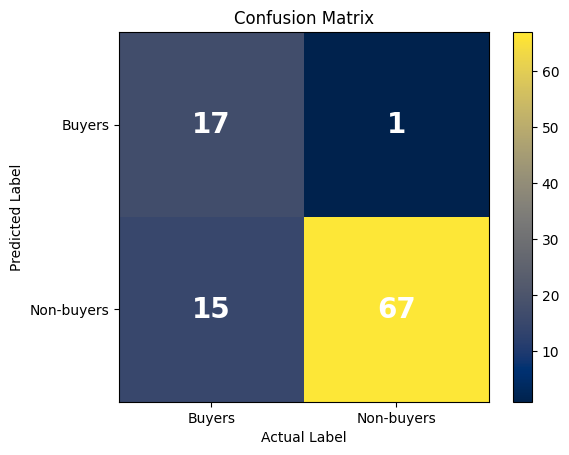

In [14]:
disp = ConfusionMatrixDisplay(cm, display_labels = ['Buyers', 'Non-buyers'])

text_kwargs = {
    'size': 20,
    'color': 'white',
    'weight': 'bold'} # or 'normal'

ax = disp.plot(cmap='cividis', text_kw = text_kwargs).ax_
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted Label')
ax.set_title('Confusion Matrix')


# Task 4:
-- Evaluation of the model by different tools

In [15]:
# -- Preparation of the classification report

from sklearn.metrics import classification_report
print(f'the Classification Report is :\n {classification_report(y_test, y_pred)}')

the Classification Report is :
               precision    recall  f1-score   support

           0       0.82      0.99      0.89        68
           1       0.94      0.53      0.68        32

    accuracy                           0.84       100
   macro avg       0.88      0.76      0.79       100
weighted avg       0.86      0.84      0.83       100



I focus on the positive cases here:

Despite having a good precession score (0.94), this model has a pretty low recall score (0.53), which could be reflected in the f1 score as well (0.68). This means that we can trust this model to be very strong in correctly identifying the buyer of cars. In other words, the cases that this model indentifies as buyers are to a great extent correct (low false positives).

On the other hand, the recall score is low which means that the number of the actual buyers that the model predicts is pretty low. In other words, there are some people buying a car but not identified (high false negative).

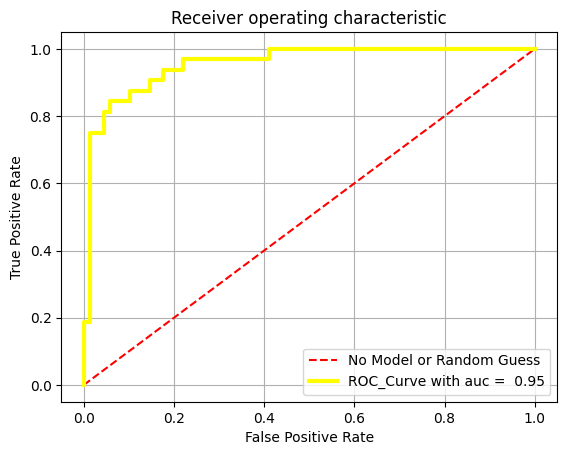

In [16]:
# Evaluation of the roc_curve and its score

from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_score_ = roc_auc_score(y_test, y_proba)

plt.plot([0, 1], [0, 1], linestyle='--', color = 'red', label = 'No Model or Random Guess')
plt.plot(fpr, tpr, color = 'yellow', linewidth = 3, label = f'ROC_Curve with auc = {roc_auc_score_: .2f}')
plt.legend()
plt.grid(True)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()

The ROC curve shows the percentage of people who bought a car and were correctly predicted as buyers (TPR) versus the percentage of people who did not buy a car but were incorrectly predicted as buyers (FPR).

The ideal ROC curve would go straight up the y-axis from (0,0) to (0,1) and then straight across the x-axis to (1,1). This would form a perfect rectangle (roc_auc_score = 1). This "perfect" curve would represent a model that achieves a 100% True Positive Rate (it identifies all actual positives correctly) with a 0% False Positive Rate (it makes no false positive predictions).

In [17]:
# Using Log Loss parameter to infer the predictive power of the model
from sklearn.metrics import log_loss

print(f'The log-loss value is:\n {log_loss(y_test, y_proba): .2f}')

The log-loss value is:
  0.27


A Log Loss of 0.27 for a binary classification model with a 30% positive / 70% negative distribution (meaning 30% of samples belong to the positive class and 70% to the negative class) is a very good result. For a model that simply predicts the prior probability of the majority class (70% negative, 30% positive), the Log Loss would be calculated as:

log_loss = -(1/N) sigma { (w1 * yi * log(pi) + w0 * (1 - yi) * log (1 - pi) }

approx 0.611

our model's Log Loss is significantly lower than this baseline (0.611), indicating that it has learned meaningful patterns in the data and is performing much better than a naive predictor (dumb guess)

this value shows that not only our model is making accurate classifications but is also producing well-calibrated probabilities. This means:

when our model says there's an 80% chance of a sample being positive, it is indeed positive roughly 80% of the time.

When it's confident about a prediction (probability close to 0 or 1), it's generally correct.

It's not making many "confident mistakes" (assigning high probability to the wrong class).

In summary, the logistic regression model has a strong Predictive Power.


## Cumulative Accuracy Profile (CAP)

Text(0.5, 1.0, 'CAP Curve')

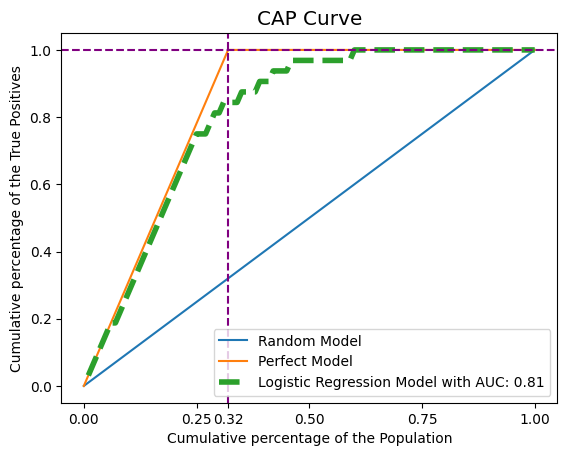

In [18]:
from sklearn.metrics import auc

total = len(y_test) # total number of the test samples
class_1 = y_test.sum() # total number of the actual positive samples in the test set
sorted_idx = np.argsort(y_proba.flatten())[::-1]  # sorting the probabilities in ascending order, getting the index for the
# sorted vector, and reversing the order of the indices.

# we need to calculate the cumulative summation of the sorted probabilities. to do this, we take advantage of cumsum() method.
# cumsum(X) takes each elements of X, sums it up to the preceding elements and puts the result in the respective index.
model_y = np.cumsum(y_test[sorted_idx])
x = np.arange(1, total + 1)

y_auc = model_y/class_1 # true positive rate
x_auc = x / total  # total sample rate

plt.plot([0, total/total], [0, class_1/class_1], label = 'Random Model')
plt.plot([0, class_1/total, total/total], [0, class_1/class_1, class_1/class_1], label = 'Perfect Model')
plt.plot(x/total, model_y/class_1,  linestyle='--', linewidth = 4,
         label= f'Logistic Regression Model with AUC: {auc(x_auc, y_auc):0.2f}')
plt.legend(loc = 'lower right')
plt.axvline(class_1/total, linestyle = '--', c = 'purple')
plt.axhline(1, linestyle = '--', c = 'purple')
plt.xticks([0, 0.25, class_1/total, 0.5, 0.75, 1])
plt.xlabel('Cumulative percentage of the Population')
plt.ylabel('Cumulative percentage of the True Positives')
plt.title('CAP Curve', fontsize = 'x-large')
